<a href="https://colab.research.google.com/github/olegovgleb-ops/01RAD/blob/main/HW/01RAD_Ex01_HW_%3CAbramkin%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/francji1/01RAD/blob/main/code/01RAD_Ex01_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01RAD - Homework 01: Cars braking distance

Investigate the relationship between the speed of a car and its stopping distance using the classic `cars` dataset (50 observations recorded in the 1920s: `speed` in mph, `dist` in ft).

Use the notation of Lecture 1: model $Y_i = \beta_0 + \beta_1 x_i + e_i$, least squares estimates $\widehat{\beta}_0, \widehat{\beta}_1$, residuals $\widehat{e}_i$, unbiased variance estimate $s_n^2 = SSE/(n-2)$.

## Submission
Work through the tasks below in this notebook (code plus short written answers in markdown cells). Python is the default, but you may equally solve the tasks in R (`lm(dist ~ speed, data = cars)`), the questions are the same.

Submit your solution through GitHub **before the next exercise**:
1. fork the course repository `francji1/01RAD`,
2. save your notebook into the `HW/` folder as `01RAD_Ex01_HW_<Surname>.ipynb` (for example `01RAD_Ex01_HW_Novak.ipynb`; for a team join the surnames with an underscore),
3. open a pull request to the `main` branch of `francji1/01RAD`.

A selected student solution and a reference solution will be published in the `HW/` folder a week later.

## Data

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', palette='deep')

url_cars = 'https://raw.githubusercontent.com/francji1/01RAD/main/data/cars.csv'
try:
    cars = pd.read_csv(url_cars)
except Exception:
    # fallback: the same data set from R's datasets package via statsmodels
    cars = sm.datasets.get_rdataset('cars', package='datasets').data
print(f'Rows: {cars.shape[0]}, columns: {cars.shape[1]}')
cars.head()

Rows: 50, columns: 2


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


## Task 01 - Inspect the data
Inspect the structure of the dataset (`info()`, `describe()`). Which variable is the response and which the explanatory variable here, and why?

The response variable is dist.The explanatory variable is speed. The distance is depends on how fast the car was traveling. In regression we use the explanatory variable to predict the response varible.

In [15]:
cars.info()
cars.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   speed   50 non-null     int64
 1   dist    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes


,count,mean,std,min,25%,50%,75%,max
speed,50.0,15.40,5.287644,4.0,12.0,15.0,19.0,25.0
dist,50.0,42.98,25.769377,2.0,26.0,36.0,56.0,120.0


## Task 02 - Plots
Plot histograms with density curves for `speed` and `dist`, and the scatter plot of `dist` against `speed`. Comment on the shape of the relationship.

As the speed increase, the distance also increase. The relationship is mostly linear, but at the end slightly it goes up.

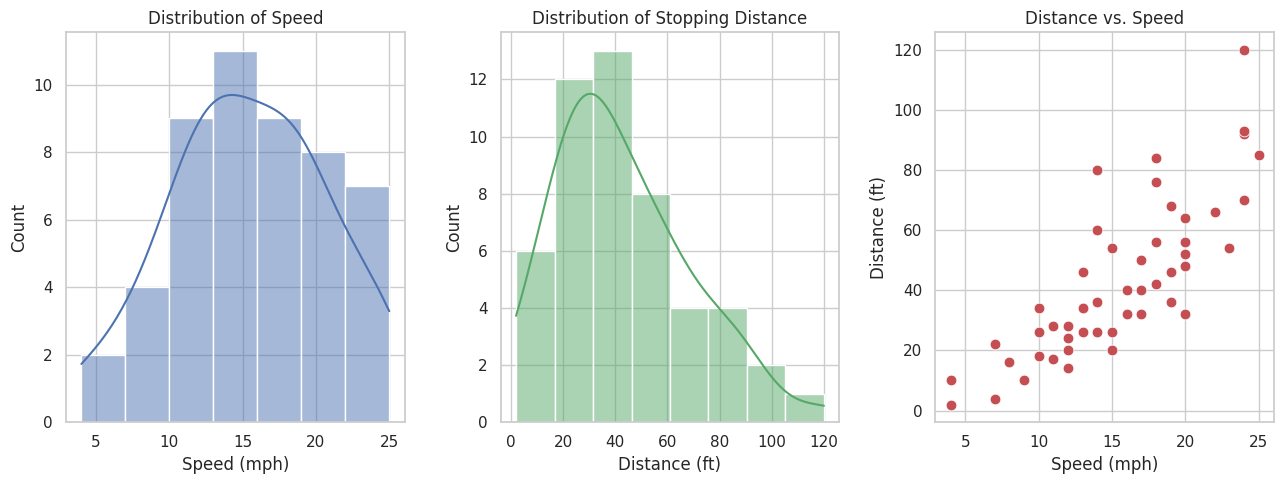

In [16]:

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

sns.histplot(data=cars, x='speed', kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Speed')
axes[0].set_xlabel('Speed (mph)')

sns.histplot(data=cars, x='dist', kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('Distribution of Stopping Distance')
axes[1].set_xlabel('Distance (ft)')


sns.scatterplot(data=cars, x='speed', y='dist', ax=axes[2], color='#C44E52', s=60)
axes[2].set_title('Distance vs. Speed')
axes[2].set_xlabel('Speed (mph)')
axes[2].set_ylabel('Distance (ft)')

plt.tight_layout()
plt.show()


## Task 03 - Least squares by hand
Fit the simple linear regression model manually, both with intercept ($Y_i = \beta_0 + \beta_1 x_i + e_i$) and without intercept ($Y_i = \beta_1 x_i + e_i$, regression through the origin). Derive $\widehat{\beta}_0$ and $\widehat{\beta}_1$ from the sums (Lecture 1, formula (2.1)); for the model without intercept derive the estimate from its single normal equation. *Hint:* minimising $\sum_i (y_i - \beta_1 x_i)^2$ gives $\widehat{\beta}_1 = \sum_i x_i y_i / \sum_i x_i^2$, see Exercise 01, section 8.

In [17]:

X = cars['speed']
Y = cars['dist']
n = len(cars)
X_mean = X.mean()
Y_mean = Y.mean()


S_xx = np.sum((X - X_mean) ** 2)
S_xy = np.sum((X - X_mean) * (Y - Y_mean))

beta1_with = S_xy / S_xx
beta0_with = Y_mean - beta1_with * X_mean


e_with = Y - (beta0_with + beta1_with * X)
s2_n_with = np.sum(e_with ** 2) / (n - 2)


beta1_origin = np.sum(X * Y) / np.sum(X ** 2)


e_origin = Y - (beta1_origin * X)
s2_n_origin = np.sum(e_origin ** 2) / (n - 1)


results = pd.DataFrame({
    'model': ['with intercept', 'through the origin'],
    'beta0': [beta0_with, 0.0],
    'beta1': [beta1_with, beta1_origin],
    's^2_n': [s2_n_with, s2_n_origin]
})

display(results)

,model,beta0,beta1,s^2_n
0,with intercept,-17.579095,3.932409,236.531689
1,through the origin,0.000000,2.909132,264.362793


## Task 04 - Residual sum of squares and $s_n^2$
Compute the residual sum of squares $SSE$ and the unbiased estimate of the error variance for each model. Mind the degrees of freedom: $n-2$ with intercept, $n-1$ without.

In [18]:

SSE_with = np.sum(e_with ** 2)

s2_n_with = SSE_with / (n - 2)

s_n_with = np.sqrt(s2_n_with)

SSE_origin = np.sum(e_origin ** 2)

s2_n_origin = SSE_origin / (n - 1)

s_n_origin = np.sqrt(s2_n_origin)

print("--- Model WITH intercept ---")
print(f"SSE:   {SSE_with:.4f}")
print(f"s^2_n: {s2_n_with:.4f}")
print(f"s_n:   {s_n_with:.4f}\n")

print("--- Model WITHOUT intercept ---")
print(f"SSE:   {SSE_origin:.4f}")
print(f"s^2_n: {s2_n_origin:.4f}")
print(f"s_n:   {s_n_origin:.4f}")


--- Model WITH intercept ---
SSE:   11353.5211
s^2_n: 236.5317
s_n:   15.3796

--- Model WITHOUT intercept ---
SSE:   12953.7768
s^2_n: 264.3628
s_n:   16.2592


## Task 05 - Standard errors
Derive the estimated variances and standard errors of the estimated parameters in both models. Check them against `statsmodels` (`.bse`). *Hint:* for the model with intercept use the formulas previewed in Exercise 01, section 7; for the model through the origin $\mathrm{Var}(\widehat{\beta}_1) = \sigma^2 / \sum_i x_i^2$, with $\sigma^2$ estimated by $s_n^2$ on $n-1$ degrees of freedom.

In [19]:

delta_0 = 1 / n + (X_mean ** 2) / S_xx
delta_1 = 1 / S_xx
var_b0_hat = s2_n_with * delta_0
var_b1_hat = s2_n_with * delta_1

se_b0 = np.sqrt(var_b0_hat)
se_b1 = np.sqrt(var_b1_hat)


delta_1_origin = 1 / np.sum(X ** 2)
var_b1_origin = s2_n_origin * delta_1_origin

se_b1_origin = np.sqrt(var_b1_origin)


print("--- MANUAL STANDARD ERRORS ---")
manual_se = pd.Series({
    'SE(beta0_hat) with intercept': se_b0,
    'SE(beta1_hat) with intercept': se_b1,
    'SE(beta1_hat) through origin': se_b1_origin,
}).map('{:.4g}'.format).to_frame('value')
display(manual_se)


print("\n--- STATSMODELS CHECK (.bse) ---")


model_with_sm = sm.OLS(Y, sm.add_constant(X)).fit()
print("Model with intercept:")
print(model_with_sm.bse.to_string())


model_origin_sm = sm.OLS(Y, X).fit()
print("\nModel through the origin:")
print(model_origin_sm.bse.to_string())


--- MANUAL STANDARD ERRORS ---


,value
SE(beta0_hat) with intercept,6.758
SE(beta1_hat) with intercept,0.4155
SE(beta1_hat) through origin,0.1414



--- STATSMODELS CHECK (.bse) ---
Model with intercept:
const    6.758440
speed    0.415513

Model through the origin:
speed    0.141369


## Task 06 - Fitted lines
Plot the data together with both fitted regression lines on the same axes.

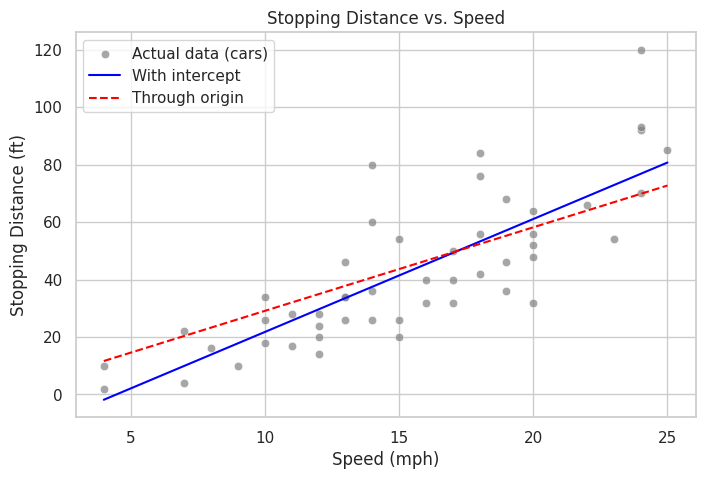

In [20]:

plt.figure(figsize=(8, 5))


sns.scatterplot(x=X, y=Y, color='grey', alpha=0.7, label='Actual data (cars)')


x_line = np.linspace(X.min(), X.max(), 100)


y_line_with = beta0_with + beta1_with * x_line
plt.plot(x_line, y_line_with, color='blue', label='With intercept')


y_line_origin = beta1_origin * x_line
plt.plot(x_line, y_line_origin, color='red', linestyle='--', label='Through origin')


plt.title('Stopping Distance vs. Speed')
plt.xlabel('Speed (mph)')
plt.ylabel('Stopping Distance (ft)')
plt.legend()
plt.show()


## Task 07 - Compare the slopes
Compare the two slopes. Why do they differ? Which model makes more physical sense for braking distance, and what does the sign of $\widehat{\beta}_0$ tell you?

The slope of the model through the origin  is lower than the slope of the model with an intercept. They differ because forcing the regression line to start exactly at (0,0) restricts the model's flexibility. The model through the origin makes more physical sense. If a car is traveling at zero speed, its braking distance must logically be exactly at zero distance. The negative sign of the intercept  indicates that a car traveling at zero speed would theoretically have a negative stopping distance. This is physically impossible.

## Task 08 - Prediction
Predict the stopping distance at 20 mph and 30 mph with both models. Are the predictions plausible? Which one is an extrapolation?


The prediction at 20 mph is plausible because it is an interpolation, because it falls within the observed speed range of 4 to 25 mph in our dataset.
The prediction at 30 mph is an extrapolation, as it lies strictly outside our data range.

In [21]:

speed_20 = 20
pred_20_with = beta0_with + beta1_with * speed_20
pred_20_origin = beta1_origin * speed_20


speed_30 = 30
pred_30_with = beta0_with + beta1_with * speed_30
pred_30_origin = beta1_origin * speed_30

print("--- Predictions at 20 mph ---")
print(f"With intercept:     {pred_20_with:.2f} ft")
print(f"Through the origin: {pred_20_origin:.2f} ft\n")

print("--- Predictions at 30 mph ---")
print(f"With intercept:     {pred_30_with:.2f} ft")
print(f"Through the origin: {pred_30_origin:.2f} ft")


--- Predictions at 20 mph ---
With intercept:     61.07 ft
Through the origin: 58.18 ft

--- Predictions at 30 mph ---
With intercept:     100.39 ft
Through the origin: 87.27 ft


## Task 09 - Residuals
Compute and plot the residuals $\widehat{e}_i$ against the fitted values for both models. Which residual pattern looks healthier, and what does the pattern suggest?

Neither model shows a perfectly ideal random scatter.

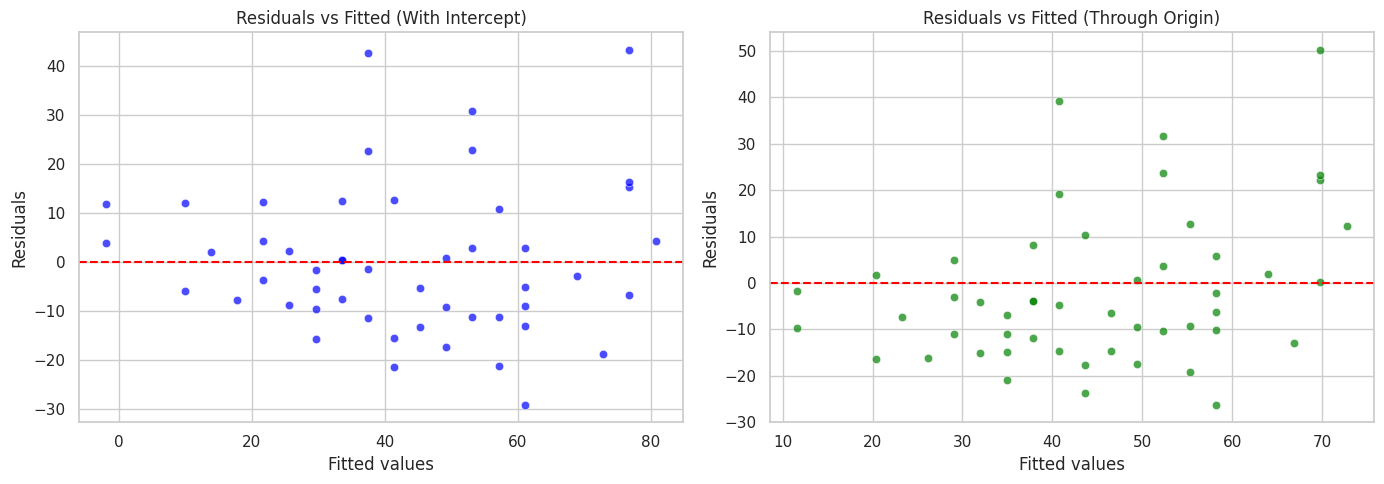

In [22]:

fitted_with = beta0_with + beta1_with * X
residuals_with = Y - fitted_with

fitted_origin = beta1_origin * X
residuals_origin = Y - fitted_origin


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=fitted_with, y=residuals_with, ax=axes[0], color='blue', alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted (With Intercept)')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')


sns.scatterplot(x=fitted_origin, y=residuals_origin, ax=axes[1], color='green', alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Fitted (Through Origin)')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()


## Task 10 - An artificial outlier
Add one artificial outlier (for example a large stopping distance at a low speed) and refit both models. How do the coefficients change? Which model is more sensitive?

The model with an intercept shifts its starting point up, and the slope changes fairly smoothly. The model through the origin reacts much more strongly

In [23]:

cars_outlier = cars.copy()

outlier_row = pd.DataFrame({'speed': [5.0], 'dist': [140.0]}, index=[len(cars) + 1])
cars_outlier = pd.concat([cars_outlier, outlier_row])

X_out = cars_outlier['speed']
Y_out = cars_outlier['dist']
n_out = len(cars_outlier)


X_mean_out = X_out.mean()
Y_mean_out = Y_out.mean()
S_xx_out = np.sum((X_out - X_mean_out)**2)
S_xy_out = np.sum((X_out - X_mean_out) * (Y_out - Y_mean_out))

beta1_with_out = S_xy_out / S_xx_out
beta0_with_out = Y_mean_out - beta1_with_out * X_mean_out

beta1_origin_out = np.sum(X_out * Y_out) / np.sum(X_out**2)


comparison_outlier = pd.DataFrame({
    'Model': [
        'With intercept (Original)', 'With intercept (With Outlier)',
        'Through origin (Original)', 'Through origin (With Outlier)'
    ],
    'beta0': [beta0_with, beta0_with_out, 0.0, 0.0],
    'beta1': [beta1_with, beta1_with_out, beta1_origin, beta1_origin_out]
})

display(comparison_outlier)


,Model,beta0,beta1
0,With intercept (Original),-17.579095,3.932409
1,With intercept (With Outlier),-0.397633,2.979715
2,Through origin (Original),0.000000,2.909132
3,Through origin (With Outlier),0.000000,2.956463


## Task 11 - Is a straight line adequate?
Reflect on whether a straight-line model in `speed` is an adequate description. Physics suggests that braking distance grows with the square of speed. Suggest at least two possible next steps (a transformation of a variable, an additional term, ...) and try one of them. Transformations and checking model adequacy are the subject of later lectures; a short reflection and one experiment are enough here.

--- Quadratic Model Summary ---
                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     47.14
Date:                Sun, 27 Sep 2026   Prob (F-statistic):           5.85e-12
Time:                        14:31:00   Log-Likelihood:                -205.39
No. Observations:                  50   AIC:                             416.8
Df Residuals:                      47   BIC:                             422.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.470

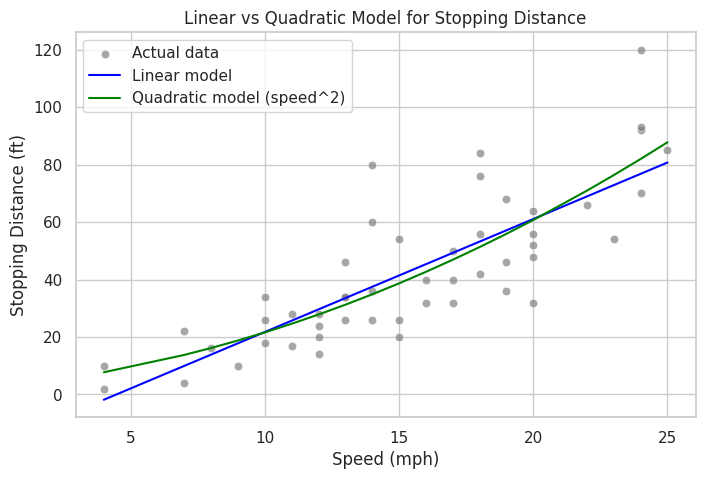

In [24]:

cars_quad = cars.copy()
cars_quad['speed_sq'] = cars_quad['speed'] ** 2


model_quad = smf.ols('dist ~ speed + speed_sq', data=cars_quad).fit()


print("--- Quadratic Model Summary ---")
print(model_quad.summary())


plt.figure(figsize=(8, 5))
sns.scatterplot(x='speed', y='dist', data=cars, color='grey', alpha=0.7, label='Actual data')


sort_idx = np.argsort(cars['speed'])
x_sorted = cars['speed'].iloc[sort_idx]


plt.plot(x_sorted, fitted_with.iloc[sort_idx], color='blue', label='Linear model')


plt.plot(x_sorted, model_quad.fittedvalues.iloc[sort_idx], color='green', linestyle='-', label='Quadratic model (speed^2)')

plt.title('Linear vs Quadratic Model for Stopping Distance')
plt.xlabel('Speed (mph)')
plt.ylabel('Stopping Distance (ft)')
plt.legend()
plt.show()
